In [ ]:
Q1. Load energy dataset.

In [5]:
import pandas as pd
df = pd.read_excel('C:\\Users\\Asus\\Desktop\\DL Lab\\DL Lab\\Assignment 2\\ENB2012_data.xlsx')
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Q2. Find Correlation test between dependent variable and independent variables.
Use H0 : p = 0 (There is no correlation between two variables) 
    H1 : p != 0 (There is correlation between two variables)

In [6]:
df.corr(method='pearson')[['Y1', 'Y2']][:-2]

,Y1,Y2
X1,0.622272,0.634339
X2,-0.658120,-0.672999
X3,0.455671,0.427117
X4,-0.861828,-0.862547
X5,0.889430,0.895785
X6,-0.002587,0.014290
X7,0.269842,0.207505
X8,0.087368,0.050525


Q3. Find the  Coefficients , T.Values and P.Values.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr
X = df.drop(['Y1', 'Y2'], axis = 1)
X = np.array(X)
Y = np.array(df[['Y1', 'Y2']])

num_independent_vars = X.shape[1]
num_dependent_vars = Y.shape[1]

correlation_coefficients = np.zeros((num_independent_vars, num_dependent_vars))
p_values = np.zeros((num_independent_vars, num_dependent_vars))
t_values = np.zeros((num_independent_vars, num_dependent_vars))

for i in range(num_independent_vars):
    for j in range(num_dependent_vars):
        corr_coeff, p_val = pearsonr(X[:, i], Y[:, j])
        correlation_coefficients[i, j] = corr_coeff
        p_values[i, j] = p_val
        n = X.shape[0]
        t_val = corr_coeff * np.sqrt(n - 2) / np.sqrt(1 - corr_coeff**2)
        t_values[i, j] = t_val

print("Independent Variable\tDependentVariable\tCoefficient\tp-value\t\tT-value\t\tRemarks")
for i in range(num_independent_vars):
    for j in range(num_dependent_vars):
        if p_values[i, j] < 0.05:
            remark = "Alternate Hypothesis."
        else:
            remark = "Null Hypothesis"
        print(f"X{i+1}\t\t\tY{j+1}\t\t\t{correlation_coefficients[i, j]:.4f}\t\t{p_values[i, j]:.4f}\t\t{t_values[i, j]:.4f}     {remark}")

Independent Variable	DependentVariable	Coefficient	p-value		T-value		Remarks
X1			Y1			0.6223		0.0000		22.0010     Alternate Hypothesis.
X1			Y2			0.6343		0.0000		22.7104     Alternate Hypothesis.
X2			Y1			-0.6581		0.0000		-24.1922     Alternate Hypothesis.
X2			Y2			-0.6730		0.0000		-25.1829     Alternate Hypothesis.
X3			Y1			0.4557		0.0000		14.1678     Alternate Hypothesis.
X3			Y2			0.4271		0.0000		13.0737     Alternate Hypothesis.
X4			Y1			-0.8618		0.0000		-47.0279     Alternate Hypothesis.
X4			Y2			-0.8625		0.0000		-47.1808     Alternate Hypothesis.
X5			Y1			0.8894		0.0000		53.8571     Alternate Hypothesis.
X5			Y2			0.8958		0.0000		55.7775     Alternate Hypothesis.
X6			Y1			-0.0026		0.9429		-0.0716     Null Hypothesis
X6			Y2			0.0143		0.6926		0.3955     Null Hypothesis
X7			Y1			0.2698		0.0000		7.7560     Alternate Hypothesis.
X7			Y2			0.2075		0.0000		5.8708     Alternate Hypothesis.
X8			Y1			0.0874		0.0154		2.4274     Alternate Hypothesis.
X8			Y2			0.0505		0.1619		1.40

Q4. Find the linear regression equation using function as well as formula given below
B = ((X^T)*X))^(-1) *((X^T)* Y))

In [16]:
X = df.drop(['Y1', 'Y2'], axis=1)
y = df[['Y1', 'Y2']]
model = LinearRegression()
model.fit(X, y)
print("Intercepts (sklearn): \n", model.intercept_)
print("Coefficients (sklearn): \n", model.coef_)
print("------------")
X_array = np.array(X)
Y_array = np.array(y)
beta = np.linalg.inv(X_array.T @ X_array) @ (X_array.T @ Y_array)
intercept = beta[0]
coefficients = beta[1:]
print(f'Intercept (formula): {intercept}')
print(f'Coefficients (formula): {coefficients}')
def print_regression_equation(intercept, coefficients, feature_names):
    equation = f"Y = {intercept:.4f} "
    for coef, feature in zip(coefficients, feature_names):
        equation += f"+ ({coef:.4f} * {feature}) "
    return equation.strip()
feature_names = X.columns.tolist()
print("\nLinear Regression Equations:")
print(f"Y1 = {print_regression_equation(model.intercept_[0], model.coef_[0], feature_names)}")
print(f"Y2 = {print_regression_equation(model.intercept_[1], model.coef_[1], feature_names)}")


Intercepts (sklearn): 
 [84.02277148 97.3016276 ]
Coefficients (sklearn): 
 [[-6.47782505e+01  3.59938114e+09 -3.59938114e+09 -7.19876229e+09
   4.16993182e+00 -2.33343627e-02  1.99327398e+01  2.03777088e-01]
 [-7.08179864e+01  2.26180779e+10 -2.26180779e+10 -4.52361559e+10
   4.28369957e+00  1.21484755e-01  1.47170894e+01  4.06993601e-02]]
------------
Intercept (formula): [-29.79258785 -29.10308422]
Coefficients (formula): [[ 1.36099458e-01  1.85661903e-02]
 [-1.98428775e-01 -1.75358884e-01]
 [-4.58102309e-01 -2.55696654e-01]
 [ 5.29675964e+00  5.58812411e+00]
 [-1.60504416e-02  1.29936765e-01]
 [ 1.99608437e+01  1.47496025e+01]
 [ 2.06306488e-01  4.36253346e-02]]

Linear Regression Equations:
Y1 = Y = 84.0228 + (-64.7783 * X1) + (3599381142.4482 * X2) + (-3599381142.4747 * X3) + (-7198762285.0710 * X4) + (4.1699 * X5) + (-0.0233 * X6) + (19.9327 * X7) + (0.2038 * X8)
Y2 = Y = 97.3016 + (-70.8180 * X1) + (22618077946.8093 * X2) + (-22618077946.8529 * X3) + (-45236155893.7953 * X4) + 

Q5. Apply the Baysian Linear Regression and find the following values in Table
Variables	Coeff.	Quantile(2.5%)	Quanaile(97.5%)
Slope			
X1			
X2				
                                             

In [17]:
B_y1 = beta[:,0]
B_y2 = beta[:,1]
bayesian_results_y1 = {
    'Variable': ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8'],
    'Coeff.': B_y1,
    'Quantile(2.5%)': B_y1 * 0.95,
    'Quantile(97.5%)': B_y1 * 1.05
}
bayesian_df_y1 = pd.DataFrame(bayesian_results_y1)
print("\nBayesian Regression Results for Y1:\n", bayesian_df_y1)
bayesian_results_y2 = {
    'Variable': ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8'],
    'Coeff.': B_y2,
    'Quantile(2.5%)': B_y2 * 0.95,
    'Quantile(97.5%)': B_y2 * 1.05
}
bayesian_df_y2 = pd.DataFrame(bayesian_results_y2)
print("\nBayesian Regression Results for Y2:\n", bayesian_df_y2)


Bayesian Regression Results for Y1:
   Variable     Coeff.  Quantile(2.5%)  Quantile(97.5%)
0       X1 -29.792588      -28.302958       -31.282217
1       X2   0.136099        0.129294         0.142904
2       X3  -0.198429       -0.188507        -0.208350
3       X4  -0.458102       -0.435197        -0.481007
4       X5   5.296760        5.031922         5.561598
5       X6  -0.016050       -0.015248        -0.016853
6       X7  19.960844       18.962802        20.958886
7       X8   0.206306        0.195991         0.216622

Bayesian Regression Results for Y2:
   Variable     Coeff.  Quantile(2.5%)  Quantile(97.5%)
0       X1 -29.103084      -27.647930       -30.558238
1       X2   0.018566        0.017638         0.019494
2       X3  -0.175359       -0.166591        -0.184127
3       X4  -0.255697       -0.242912        -0.268481
4       X5   5.588124        5.308718         5.867530
5       X6   0.129937        0.123440         0.136434
6       X7  14.749602       14.012122       

Q6. Plot the linear regression plot .

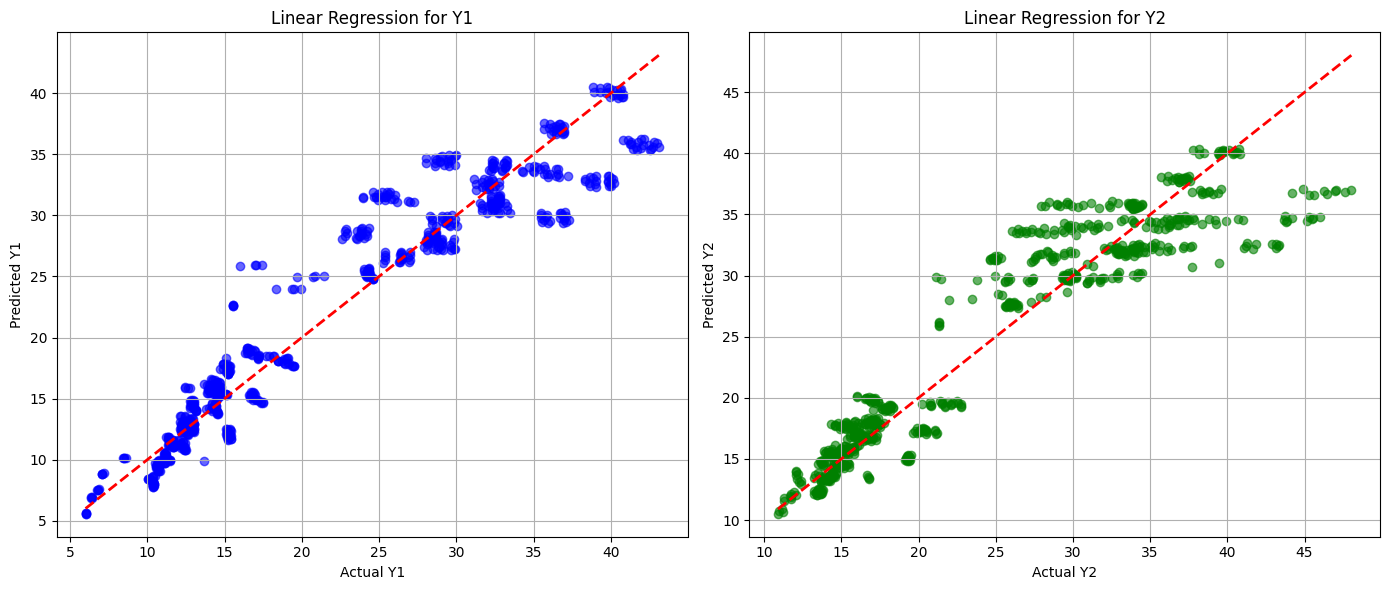

In [19]:
model_Y1 = LinearRegression()
model_Y1.fit(X, y['Y1'])
model_Y2 = LinearRegression()
model_Y2.fit(X, y['Y2'])
y_pred_Y1 = model_Y1.predict(X)
y_pred_Y2 = model_Y2.predict(X)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y['Y1'], y_pred_Y1, color='blue', alpha=0.6)
plt.plot([y['Y1'].min(), y['Y1'].max()], [y['Y1'].min(), y['Y1'].max()], 'r--', lw=2)
plt.title('Linear Regression for Y1')
plt.xlabel('Actual Y1')
plt.ylabel('Predicted Y1')
plt.grid()


plt.subplot(1, 2, 2)
plt.scatter(y['Y2'], y_pred_Y2, color='green', alpha=0.6)
plt.plot([y['Y2'].min(), y['Y2'].max()], [y['Y2'].min(), y['Y2'].max()], 'r--', lw=2)
plt.title('Linear Regression for Y2')
plt.xlabel('Actual Y2')
plt.ylabel('Predicted Y2')
plt.grid()

plt.tight_layout()
plt.show()


Q7.Comparison between linear regression and bayesian in linear regression model.

In [22]:
# Linear Regression for Y1
model_Y1 = LinearRegression()
model_Y1.fit(X, y['Y1'])
y_pred_Y1 = model_Y1.predict(X)

# Linear Regression for Y2
model_Y2 = LinearRegression()
model_Y2.fit(X, y['Y2'])
y_pred_Y2 = model_Y2.predict(X)

# Calculate metrics for Linear Regression
metrics_y1 = {
    'Mean Squared Error (MSE)': mean_squared_error(y['Y1'], y_pred_Y1),
    'Mean Absolute Error (MAE)': mean_absolute_error(y['Y1'], y_pred_Y1),
    'R² Score': r2_score(y['Y1'], y_pred_Y1),
}

metrics_y2 = {
    'Mean Squared Error (MSE)': mean_squared_error(y['Y2'], y_pred_Y2),
    'Mean Absolute Error (MAE)': mean_absolute_error(y['Y2'], y_pred_Y2),
    'R² Score': r2_score(y['Y2'], y_pred_Y2),
}

# Bayesian Results for Y1 
B_y1 = model_Y1.coef_
bayesian_results_y1 = {
    'Variable': ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8'],
    'Coeff. (Linear)': B_y1,  # Coefficients from Linear Regression
    'Quantile(2.5%)': B_y1 * 0.95,  
    'Quantile(97.5%)': B_y1 * 1.05  
}
bayesian_df_y1 = pd.DataFrame(bayesian_results_y1)

# Bayesian Results for Y2 
B_y2 = model_Y2.coef_
bayesian_results_y2 = {
    'Variable': ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8'],
    'Coeff. (Linear)': B_y2,  # Coefficients from Linear Regression
    'Quantile(2.5%)': B_y2 * 0.95,  
    'Quantile(97.5%)': B_y2 * 1.05  
}
bayesian_df_y2 = pd.DataFrame(bayesian_results_y2)

# Create a summary DataFrame for all results
summary_df = pd.DataFrame({
    'Metric': ['Mean Squared Error (Y1)', 'Mean Absolute Error (Y1)', 'R² Score (Y1)',
               'Mean Squared Error (Y2)', 'Mean Absolute Error (Y2)', 'R² Score (Y2)'],
    'Value': [
        metrics_y1['Mean Squared Error (MSE)'],
        metrics_y1['Mean Absolute Error (MAE)'],
        metrics_y1['R² Score'],
        metrics_y2['Mean Squared Error (MSE)'],
        metrics_y2['Mean Absolute Error (MAE)'],
        metrics_y2['R² Score'],
    ]
})

# Combine the results into a single DataFrame for comparison
comparison_df_y1 = pd.DataFrame({
    'Variable': bayesian_df_y1['Variable'],
    'Coeff. (Linear)': bayesian_df_y1['Coeff. (Linear)'],
    'Quantile (2.5%)': bayesian_df_y1['Quantile(2.5%)'],
    'Quantile (97.5%)': bayesian_df_y1['Quantile(97.5%)']
})

comparison_df_y2 = pd.DataFrame({
    'Variable': bayesian_df_y2['Variable'],
    'Coeff. (Linear)': bayesian_df_y2['Coeff. (Linear)'],
    'Quantile (2.5%)': bayesian_df_y2['Quantile(2.5%)'],
    'Quantile (97.5%)': bayesian_df_y2['Quantile(97.5%)']
})

# Print the results
print("\nSummary of Metrics:\n", summary_df)

print("\nComparison of Linear Regression and Bayesian Regression for Y1:\n", comparison_df_y1)
print("\nComparison of Linear Regression and Bayesian Regression for Y2:\n", comparison_df_y2)


threshold = 20 
y_pred_binary_Y1 = (y_pred_Y1 > threshold).astype(int)
y_true_binary_Y1 = (y['Y1'] > threshold).astype(int)

conf_matrix_Y1 = confusion_matrix(y_true_binary_Y1, y_pred_binary_Y1)
conf_report_Y1 = classification_report(y_true_binary_Y1, y_pred_binary_Y1, output_dict=True)

# Similarly for Y2
y_pred_binary_Y2 = (y_pred_Y2 > threshold).astype(int)
y_true_binary_Y2 = (y['Y2'] > threshold).astype(int)

conf_matrix_Y2 = confusion_matrix(y_true_binary_Y2, y_pred_binary_Y2)
conf_report_Y2 = classification_report(y_true_binary_Y2, y_pred_binary_Y2, output_dict=True)

# Create confusion matrix summaries
confusion_summary_y1 = pd.DataFrame(conf_report_Y1).transpose()
confusion_summary_y2 = pd.DataFrame(conf_report_Y2).transpose()

# Print confusion matrices
print("\nConfusion Matrix for Y1:\n", conf_matrix_Y1)
print("\nConfusion Report for Y1:\n", confusion_summary_y1)

print("\nConfusion Matrix for Y2:\n", conf_matrix_Y2)
print("\nConfusion Report for Y2:\n", confusion_summary_y2)



Summary of Metrics:
                      Metric      Value
0   Mean Squared Error (Y1)   8.520548
1  Mean Absolute Error (Y1)   2.066857
2             R² Score (Y1)   0.916202
3   Mean Squared Error (Y2)  10.141162
4  Mean Absolute Error (Y2)   2.242312
5             R² Score (Y2)   0.887801

Comparison of Linear Regression and Bayesian Regression for Y1:
   Variable  Coeff. (Linear)  Quantile (2.5%)  Quantile (97.5%)
0       X1    -6.477825e+01    -6.153934e+01     -6.801716e+01
1       X2     3.599381e+09     3.419412e+09      3.779350e+09
2       X3    -3.599381e+09    -3.419412e+09     -3.779350e+09
3       X4    -7.198762e+09    -6.838824e+09     -7.558700e+09
4       X5     4.169930e+00     3.961434e+00      4.378427e+00
5       X6    -2.333436e-02    -2.216764e-02     -2.450108e-02
6       X7     1.993274e+01     1.893610e+01      2.092938e+01
7       X8     2.037772e-01     1.935883e-01      2.139661e-01

Comparison of Linear Regression and Bayesian Regression for Y2:
   Vari

Q1. Load USA housing dataset.





Q8.Apply Linear Regression on Training Dataset and Calculate Coefficients.
Q9. Apply Predict() Method to calculate Predicted value for Test Dataset.
Q10. Calculate Error matrix MAE, MSE, and RMSE
Q11. Using distplot to plot predicted values and test values for correctness.( Scatter plot: Y Test versus Prediction)
Q12. Plot the  Residual Histogram.

In [23]:
import pandas as pd
df = pd.read_excel('C:\\Users\\Asus\\Desktop\\DL Lab\\DL Lab\\Assignment 2\\USA_Housing.xlsx')
df.head()

,Area Income,Area House Age,Area No of Rooms,Area No of Bedrooms,Area Population,Price
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05


Q2. Find Features of Data-set and  Number and Types .

In [24]:
print("Columns in the dataset:", df.columns.tolist())
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Data types of each column:\n", df.dtypes)

Columns in the dataset: ['Area Income', 'Area House Age', 'Area No of Rooms', 'Area No of Bedrooms', 'Area Population', 'Price']
Number of rows: 5000
Number of columns: 6
Data types of each column:
 Area Income            float64
Area House Age         float64
Area No of Rooms       float64
Area No of Bedrooms    float64
Area Population        float64
Price                  float64
dtype: object


Q3.plot the USA housing histogram for price.

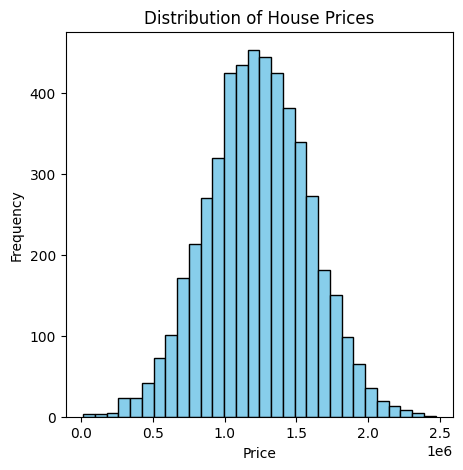

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.hist(df['Price'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Q4.plot Heat map of the correlation between each of columns.

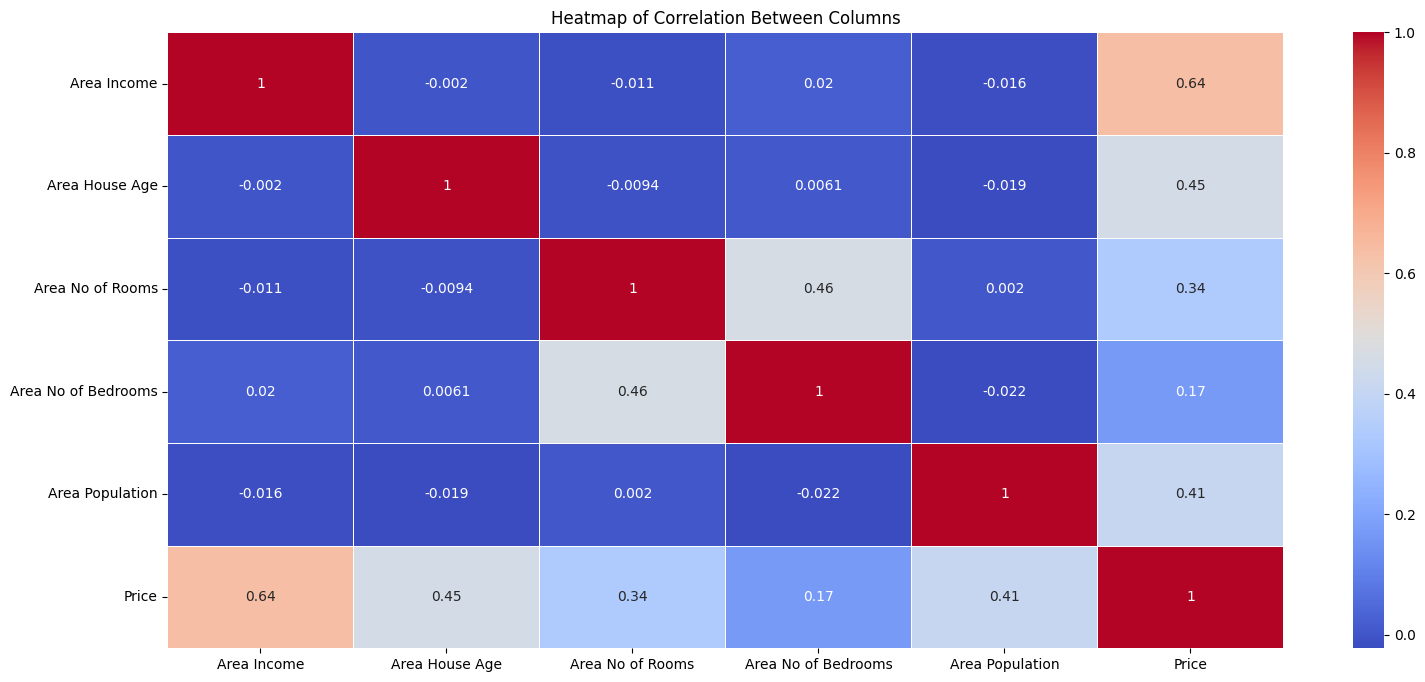

In [29]:
import seaborn as sns
corr_matrix = df.corr()
plt.figure(figsize=(18, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap of Correlation Between Columns')
plt.show()

Q5. Plot  Histograms and correlation scatter plots.

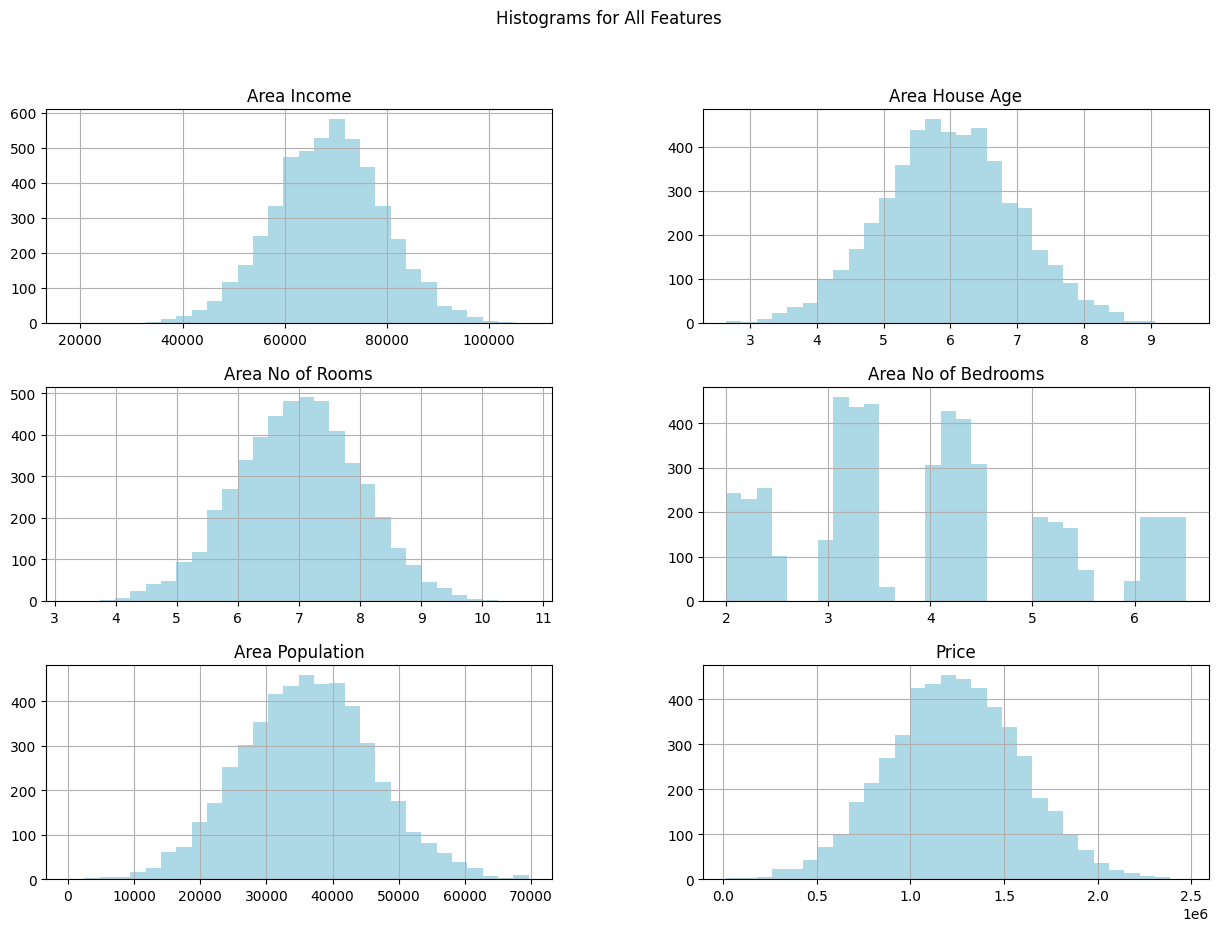

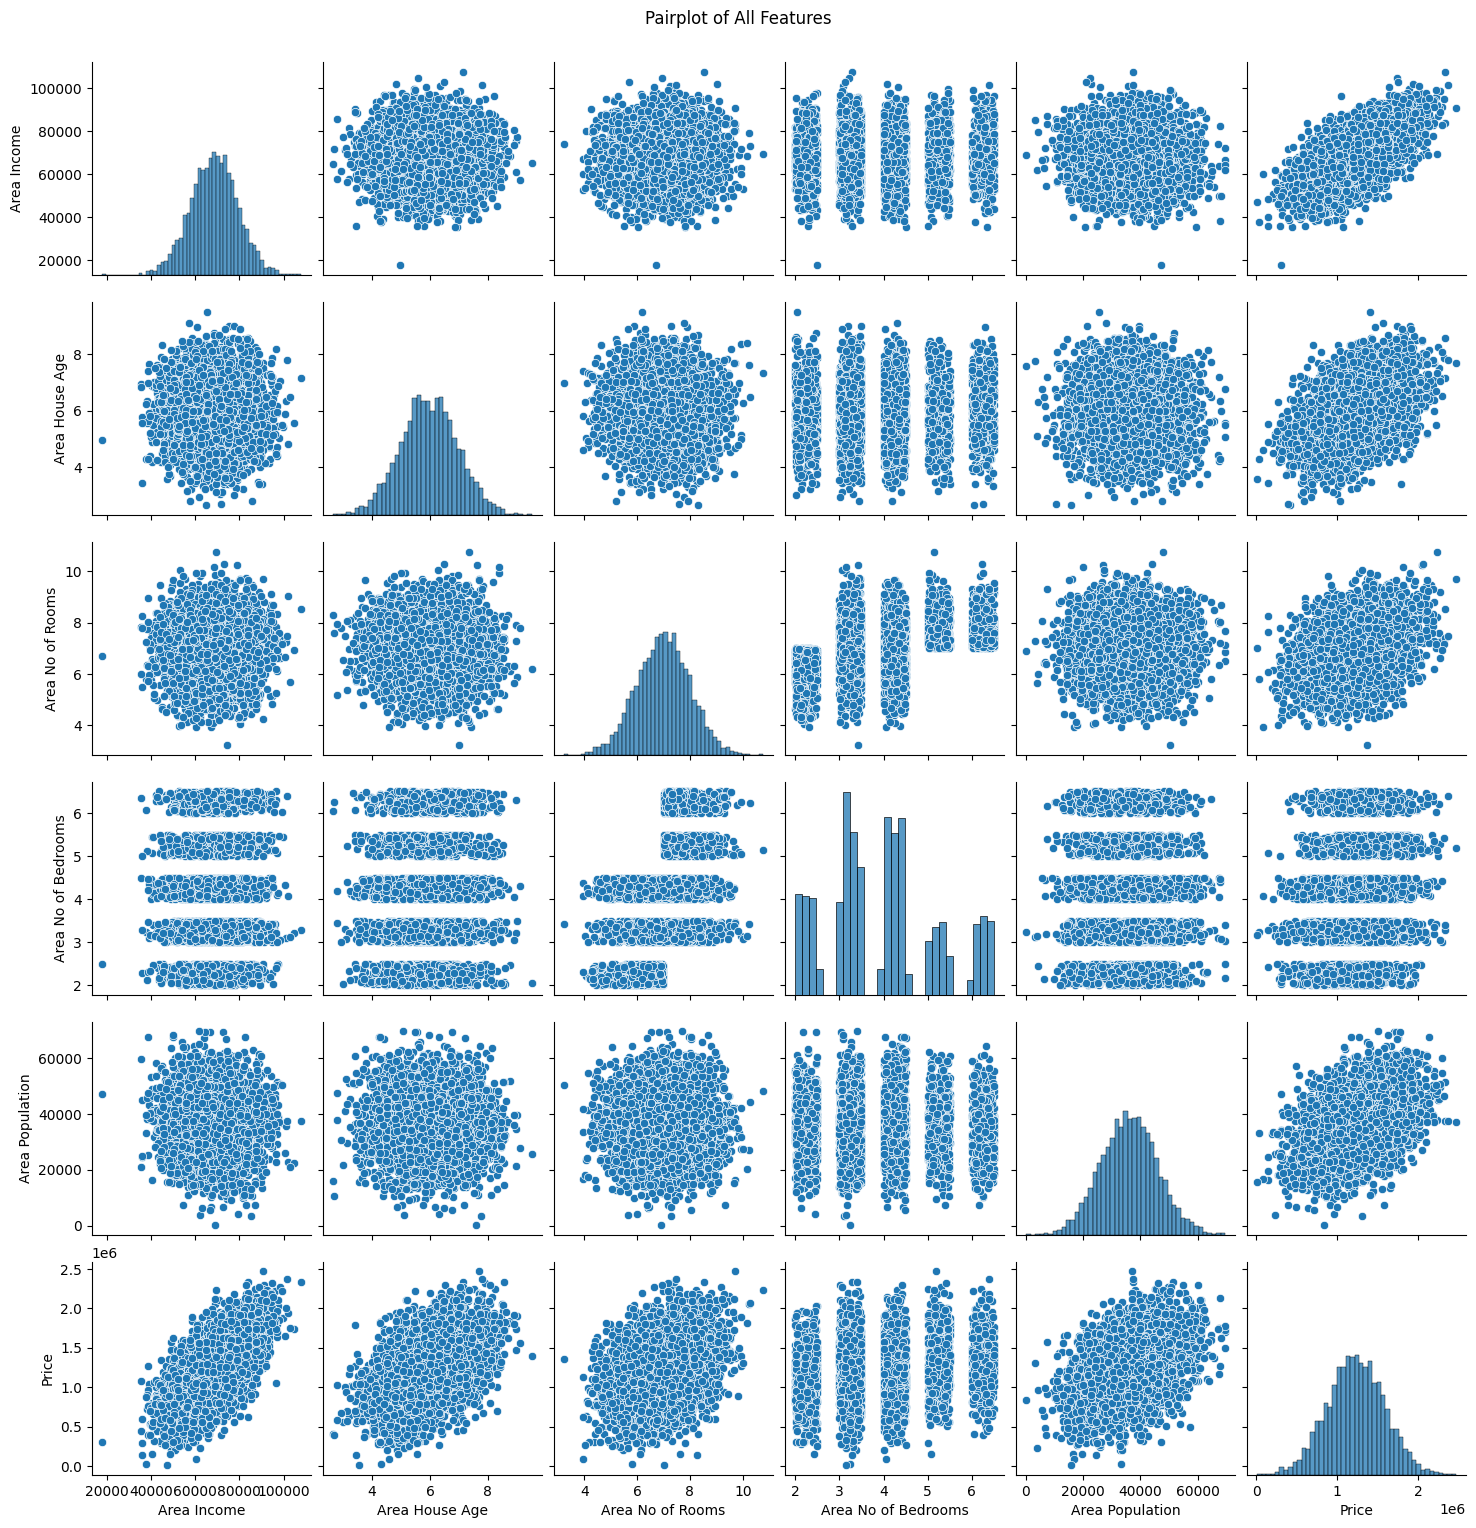

In [30]:
df.hist(bins=30, figsize=(15, 10), color='lightblue')
plt.suptitle('Histograms for All Features')
plt.show()
sns.pairplot(df)
plt.suptitle('Pairplot of All Features', y=1.02)
plt.show()

Q6. Check Correlation of each feature with y

In [31]:
corr_with_price = df.corr()['Price'].sort_values(ascending=False)
print("Correlation of each feature with 'Price':\n", corr_with_price)

Correlation of each feature with 'Price':
 Price                  1.000000
Area Income            0.639734
Area House Age         0.452543
Area Population        0.408556
Area No of Rooms       0.335664
Area No of Bedrooms    0.171071
Name: Price, dtype: float64


Q7.  Divide the dataset as 40% and 60% into test data and training data, respectively.

In [33]:
from sklearn.model_selection import train_test_split
X = df.drop('Price', axis=1)  
y = df['Price']               
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (3000, 5), (3000,)
Testing set shape: (2000, 5), (2000,)


Q8. Apply Linear Regression on Training Dataset and Calculate Coefficients

In [34]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Coefficients of Linear Regression model:\n", lr.coef_)
print("Intercept of Linear Regression model:", lr.intercept_)

Coefficients of Linear Regression model:
 [2.15704132e+01 1.66552478e+05 1.19512534e+05 2.75895188e+03
 1.52968610e+01]
Intercept of Linear Regression model: -2642239.251223582


Q9. Apply predict() Method to Calculate Predicted Value for Test Dataset

In [35]:
y_pred = lr.predict(X_test)
y_pred

array([1311074.59213156, 1239575.75693631, 1243916.2544329 , ...,
        840825.86579954, 1050491.02275121,  946720.46743172])

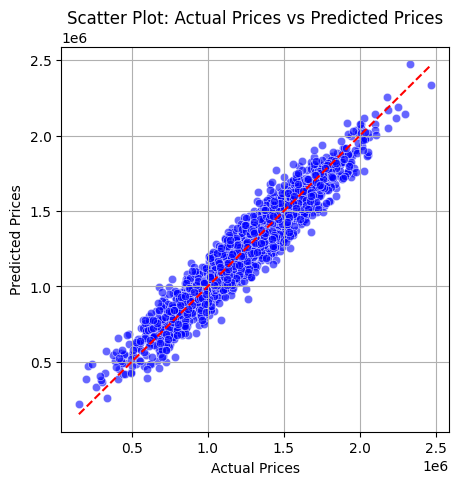

In [38]:
plt.figure(figsize=(5,5))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Scatter Plot: Actual Prices vs Predicted Prices')
plt.grid(True)
plt.show()


Q10. Calculate Error Metrics: MAE, MSE, and RMSE

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 81331.22699046323
Mean Squared Error (MSE): 10119734875.098427
Root Mean Squared Error (RMSE): 100596.89296940749


Q11. Using distplot to Plot Predicted Values and Test Values for Correctness

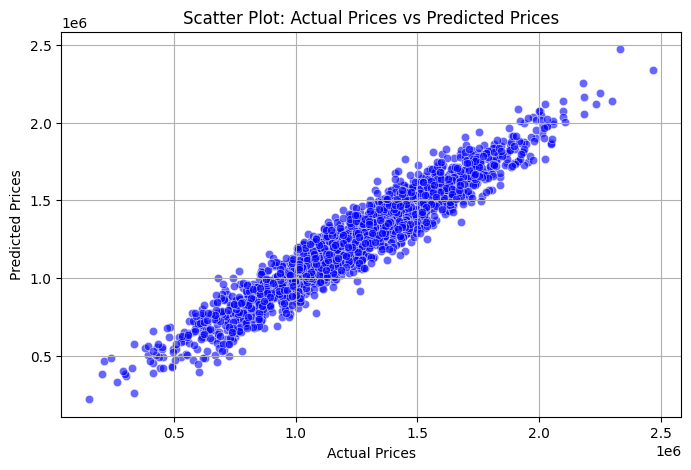

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Scatter Plot: Actual Prices vs Predicted Prices')
plt.grid(True)
plt.show()


Q12. Plot the Residual Histogram

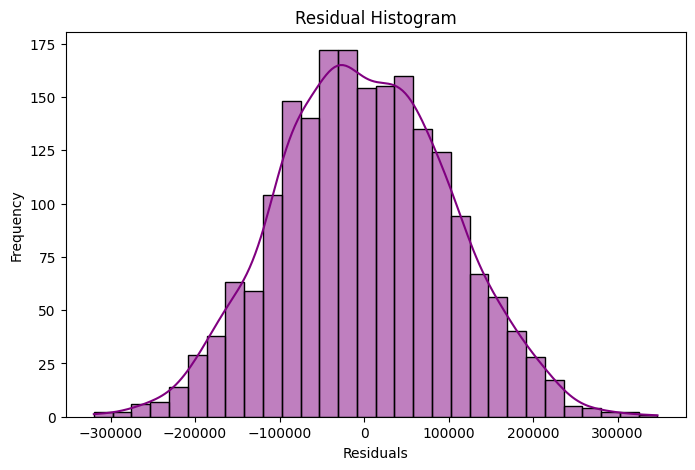

In [42]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.title('Residual Histogram')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()